## HeadHunter (вакансии с зарплатами)

In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## ПАРСИНГ ДАННЫХ С HEADHUNTER

In [10]:
def parse_hh_vacancies(search_query="data scientist", pages=3, per_page=20):
    """
    Парсинг вакансий с HeadHunter через официальное API
    Собирает: название, описание (HTML), зарплату (целевая переменная)
    """
    base_url = "https://api.hh.ru/vacancies"
    data = []
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    print(f"Сбор вакансий по запросу: '{search_query}'")
    
    for page in range(pages):
        # Параметры запроса
        params = {
            "text": search_query,
            "page": page,
            "per_page": per_page,
            "only_with_salary": True  # только вакансии с указанной зарплатой
        }
        
        try:
            # Получаю список вакансий
            response = requests.get(base_url, params=params, headers=headers, timeout=10)
            response.raise_for_status()
            vacancies = response.json().get("items", [])
            
            print(f"Страница {page + 1}: найдено {len(vacancies)} вакансий с зарплатой")
            
            # Прохожу по каждой вакансии для получения деталей
            for i, vac in enumerate(vacancies):
                try:
                    vac_id = vac["id"]
                    vac_url = f"{base_url}/{vac_id}"
                    
                    # Получаю детальную информацию
                    vac_response = requests.get(vac_url, headers=headers, timeout=10)
                    vac_response.raise_for_status()
                    vac_details = vac_response.json()
                    
                    # Текстовое описание (название + описание)
                    name = vac_details.get("name", "")
                    description_html = vac_details.get("description", "")
                    
                    # Очистка HTML-тегов
                    soup = BeautifulSoup(description_html, "html.parser")
                    description_text = soup.get_text(separator=" ", strip=True)
                    
                    # Объединяю название и описание
                    full_text = f"{name}. {description_text}"
                    
                    # Целевая переменная - зарплата (среднее between from и to)
                    salary = vac_details.get("salary", {})
                    if salary and salary.get("currency") == "RUR":  # беру только рубли
                        salary_from = salary.get("from")
                        salary_to = salary.get("to")
                        
                        if salary_from and salary_to:
                            target_salary = (salary_from + salary_to) / 2
                        elif salary_from:
                            target_salary = salary_from
                        elif salary_to:
                            target_salary = salary_to
                        else:
                            continue
                        
                        # Дополнительные признаки для анализа
                        experience = vac_details.get("experience", {}).get("name", "Не указано")
                        schedule = vac_details.get("schedule", {}).get("name", "Не указано")
                        
                        data.append({
                            "title": name,
                            "text": full_text,
                            "salary": target_salary,  # целевая переменная (непрерывная)
                            "experience": experience,
                            "schedule": schedule,
                            "url": vac_details.get("alternate_url", "")
                        })
                    
                    # задержка
                    time.sleep(0.3)
                    
                except Exception as e:
                    print(f"  Ошибка при обработке вакансии {vac_id}: {e}")
                    continue
            
            # Задержка между страницами
            time.sleep(0.5)
            
        except Exception as e:
            print(f"Ошибка при получении страницы {page}: {e}")
            continue
    
    df = pd.DataFrame(data)
    return df


In [11]:
# Запуск парсера
df = parse_hh_vacancies(search_query="python разработчик", pages=3, per_page=20)

Сбор вакансий по запросу: 'python разработчик'
Страница 1: найдено 20 вакансий с зарплатой
Страница 2: найдено 20 вакансий с зарплатой
Страница 3: найдено 20 вакансий с зарплатой


In [12]:
# Сохраняю для возможной повторной работы без повторного парсинга
df.to_csv("hh_vacancies.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Парсинг завершен! Собрано {len(df)} вакансий")
print(f"Средняя зарплата в выборке: {df['salary'].mean():.0f} руб.")
print(f"Диапазон зарплат: {df['salary'].min():.0f} - {df['salary'].max():.0f} руб.")


✓ Парсинг завершен! Собрано 52 вакансий
Средняя зарплата в выборке: 204519 руб.
Диапазон зарплат: 50000 - 450000 руб.


In [14]:
# Проверка на минимальное количество данных (защита от пустого датасета)
if len(df) < 10:
    print("\n ВНИМАНИЕ: Собрано слишком мало данных!...")
    np.random.seed(42)
    n_samples = 100
    texts = [
        "Junior python developer django flask junior начинающий стажер",
        "Senior python developer teamlead архитектор senior lead",
        "Middle python developer pandas numpy数据分析 machine learning",
        "Python разработчик удаленка гибкий график полный день"
    ]
    df = pd.DataFrame({
        'text': np.random.choice(texts, n_samples),
        'salary': np.random.normal(150000, 50000, n_samples).clip(50000, 300000)
    })


## ПРЕДОБРАБОТКА ТЕКСТА (TF-IDF)

In [15]:
# Дополнительная очистка текста (удаляю спецсимволы, оставляю только буквы и пробелы)
def clean_text(text):
    # Привожу к нижнему регистру
    text = text.lower()
    # Оставляю только русские и английские буквы и пробелы
    text = re.sub(r'[^a-zа-яё\s]', ' ', text)
    # Убираю лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [16]:
df['clean_text'] = df['text'].apply(clean_text)

In [17]:
# Разбиение на train/test (25% на тест)
X = df['clean_text']
y = df['salary']  # непрерывная целевая переменная

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 39
Размер тестовой выборки: 13


In [19]:
# Русские стоп-слова (расширенный список)
russian_stop_words = [
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все',
    'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по',
    'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из',
    'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или',
    'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь',
    'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть',
    'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без',
    'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто',
    'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом',
    'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем',
    'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть',
    'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них',
    'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впрочем', 'хорошо', 'свою',
    'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том', 'нельзя', 'такой', 'им',
    'более', 'всегда', 'конечно', 'всю', 'между', 'требования', 'обязанности', 
    'условия', 'работа', 'работы', 'компания', 'опыт', 'знание', 'навыки'
]

In [20]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),           # униграммы и биграммы
    stop_words=russian_stop_words, # русские стоп-слова
    min_df=2,                     # слово встречается минимум в 2 документах
    max_df=0.7,                   # слово не встречается более чем в 70% документов
    norm=None,                    # отключаю l2 регуляризацию
    max_features=5000,            # ограничение размерности для скорости
    token_pattern=r'\b[a-zа-яё]{3,}\b'  # только слова длиной 3+ символов
)

In [24]:
# Преобразование текста в числовые признаки
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nРазмерность TF-IDF матрицы: {X_train_tfidf.shape}")
print(f"Количество признаков (слов/биграмм): {len(tfidf.get_feature_names_out())}")


Размерность TF-IDF матрицы: (39, 1810)
Количество признаков (слов/биграмм): 1810


## ПОСТРОЕНИЕ МОДЕЛИ И ВИЗУАЛИЗАЦИЯ

In [25]:
# Линейная регрессия с регуляризацией (Ridge)
# Настройка параметра регуляризации alpha через GridSearchCV
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # перебираю разную силу регуляризации
}

ridge = Ridge(random_state=42)
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=5,  # 5-fold кросс-валидация
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [26]:
print("Подбираю оптимальный параметр регуляризации (alpha)...")
grid_search.fit(X_train_tfidf, y_train)

best_alpha = grid_search.best_params_['alpha']
print(f" Лучший параметр alpha: {best_alpha}")

Подбираю оптимальный параметр регуляризации (alpha)...
 Лучший параметр alpha: 0.001


In [27]:
# Лучшая модель
best_model = grid_search.best_estimator_

# Предсказания на тесте
y_pred = best_model.predict(X_test_tfidf)

# Оценка качества (соответствующие задаче метрики для регрессии)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [28]:
print(f"\nМЕТРИКИ КАЧЕСТВА МОДЕЛИ:")
print(f"• MSE (Mean Squared Error): {mse:.2f}")
print(f"• MAE (Mean Absolute Error): {mae:.2f} руб.")
print(f"• R² (коэффициент детерминации): {r2:.4f}")
print(f"  (R² = {r2:.2%} дисперсии объясняется моделью)")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ:
• MSE (Mean Squared Error): 5710028899.15
• MAE (Mean Absolute Error): 48823.84 руб.
• R² (коэффициент детерминации): -0.0770
  (R² = -7.70% дисперсии объясняется моделью)


In [29]:
# Примеры предсказаний
print(f"\nПримеры предсказаний:")
comparison_df = pd.DataFrame({
    'Фактическая зарплата': y_test.iloc[:5].values,
    'Предсказанная зарплата': y_pred[:5].round(0),
    'Ошибка': (y_test.iloc[:5].values - y_pred[:5]).round(0)
})
print(comparison_df.to_string(index=False))


Примеры предсказаний:
 Фактическая зарплата  Предсказанная зарплата   Ошибка
             225000.0                223601.0   1399.0
             130000.0                169162.0 -39162.0
             245000.0                212283.0  32717.0
             240000.0                191079.0  48921.0
             220000.0                200153.0  19847.0


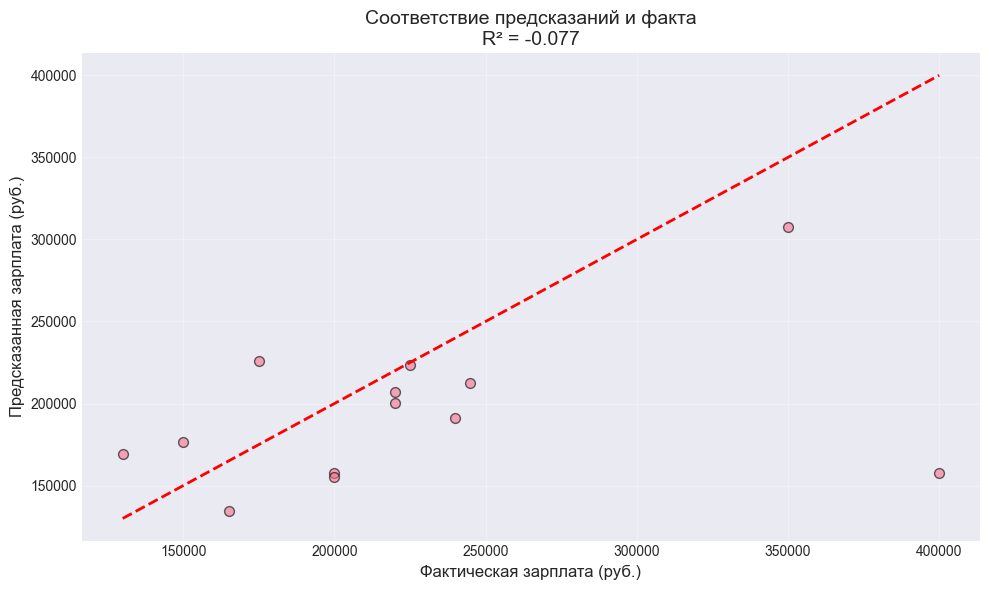

In [30]:
# Визуализация 1: Scatter plot предсказаний vs факт
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактическая зарплата (руб.)', fontsize=12)
plt.ylabel('Предсказанная зарплата (руб.)', fontsize=12)
plt.title(f'Соответствие предсказаний и факта\nR² = {r2:.3f}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

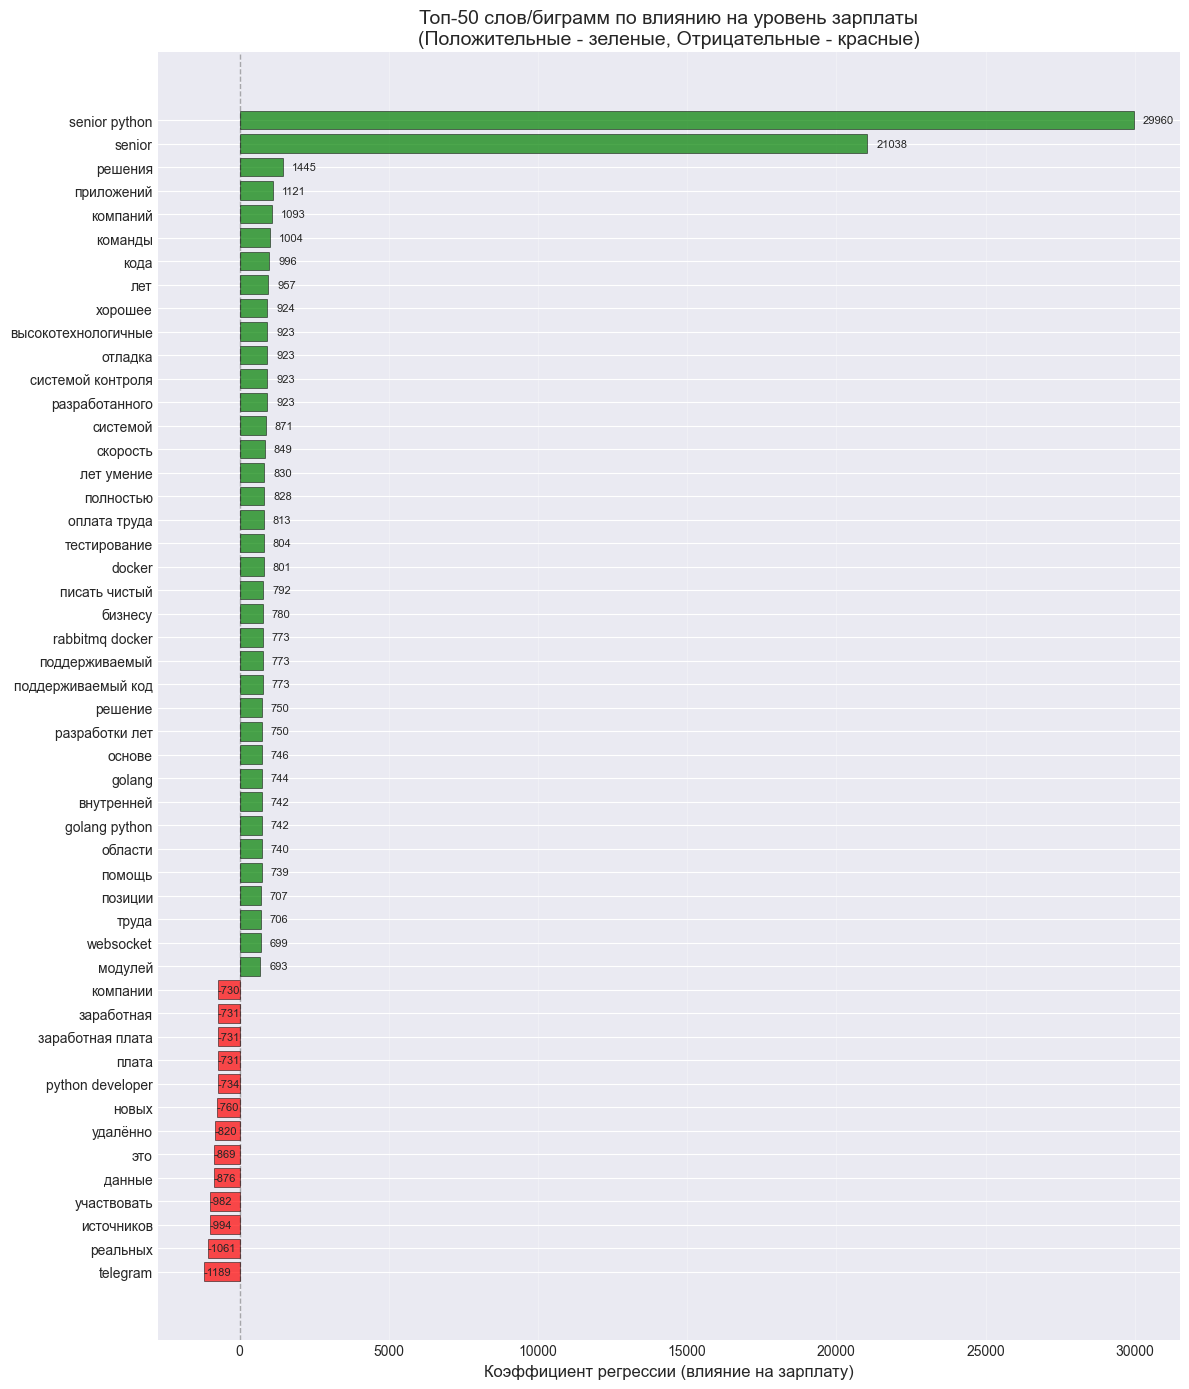

In [32]:
# Визуализация 2: Топ-50 коэффициентов регрессии
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = best_model.coef_

# Беру топ-50 по модулю значения коэффициента
top_n = 50
top_indices = np.argsort(np.abs(coefficients))[-top_n:]
top_features = feature_names[top_indices]
top_coefs = coefficients[top_indices]

# Сортирую для красивой визуализации (по возрастанию значения коэффициента)
sorted_idx = np.argsort(top_coefs)
top_features = top_features[sorted_idx]
top_coefs = top_coefs[sorted_idx]

plt.figure(figsize=(12, 14))
colors = ['red' if c < 0 else 'green' for c in top_coefs]
bars = plt.barh(range(top_n), top_coefs, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.yticks(range(top_n), top_features, fontsize=10)
plt.xlabel('Коэффициент регрессии (влияние на зарплату)', fontsize=12)
plt.title(f'Топ-{top_n} слов/биграмм по влиянию на уровень зарплаты\n(Положительные - зеленые, Отрицательные - красные)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.grid(axis='x', alpha=0.3)

# Добавляю значения на концы столбцов
for i, (coef, bar) in enumerate(zip(top_coefs, bars)):
    plt.text(coef + (max(top_coefs)*0.01 if coef > 0 else min(top_coefs)*0.01), 
             i, f'{coef:.0f}', 
             va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [33]:
print("\n" + "=" * 60)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Топ положительных и отрицательных коэффициентов
positive_words = [(feature_names[i], coefficients[i]) for i in np.argsort(coefficients)[-10:]]
negative_words = [(feature_names[i], coefficients[i]) for i in np.argsort(coefficients)[:10]]

print("\nТоп-10 слов/биграмм, УВЕЛИЧИВАЮЩИХ зарплату:")
for word, coef in reversed(positive_words):
    print(f"  + {word:<25} : +{coef:>8.0f} руб.")

print("\nТоп-10 слов/биграмм, УМЕНЬШАЮЩИХ зарплату:")
for word, coef in negative_words:
    print(f"  - {word:<25} : {coef:>9.0f} руб.")


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

Топ-10 слов/биграмм, УВЕЛИЧИВАЮЩИХ зарплату:
  + senior python             : +   29960 руб.
  + senior                    : +   21038 руб.
  + решения                   : +    1445 руб.
  + приложений                : +    1121 руб.
  + компаний                  : +    1093 руб.
  + команды                   : +    1004 руб.
  + кода                      : +     996 руб.
  + лет                       : +     957 руб.
  + хорошее                   : +     924 руб.
  + разработанного            : +     923 руб.

Топ-10 слов/биграмм, УМЕНЬШАЮЩИХ зарплату:
  - telegram                  :     -1189 руб.
  - реальных                  :     -1061 руб.
  - источников                :      -994 руб.
  - участвовать               :      -982 руб.
  - данные                    :      -876 руб.
  - это                       :      -869 руб.
  - удалённо                  :      -820 руб.
  - новых                     :      -760 руб.
  - python developer          :      